In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [65]:
df = pd.read_csv('/content/sample_data/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [66]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [67]:
df.shape

(918, 12)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [69]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [70]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

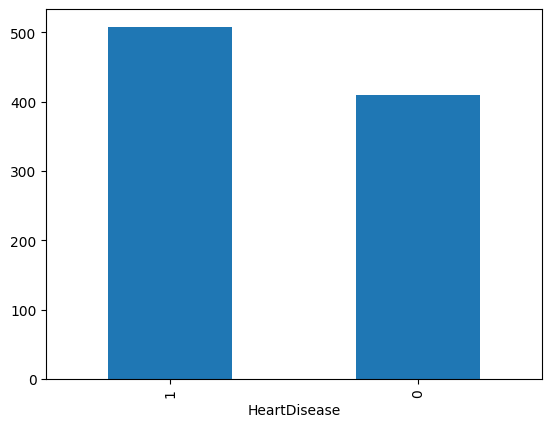

In [71]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [72]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


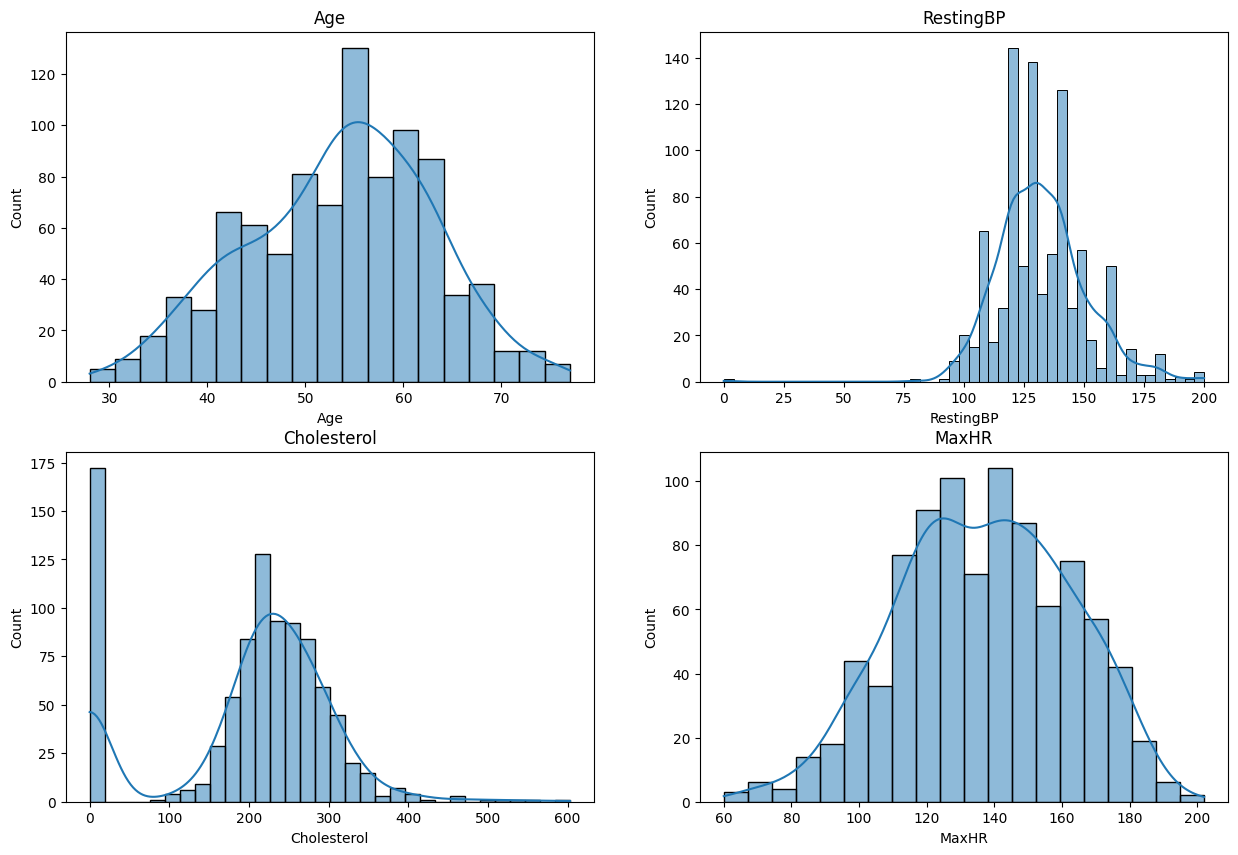

In [73]:
def plot(col,num):
    plt.subplot(2,2,num)
    sns.histplot(df[col],kde=True)
    plt.title(col)

plt.figure(figsize=(15,10))
plot('Age',1)
plot('RestingBP',2)
plot('Cholesterol',3)
plot('MaxHR',4)

In [74]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [75]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)

In [76]:
ch_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,ch_mean)

<Axes: xlabel='Sex', ylabel='count'>

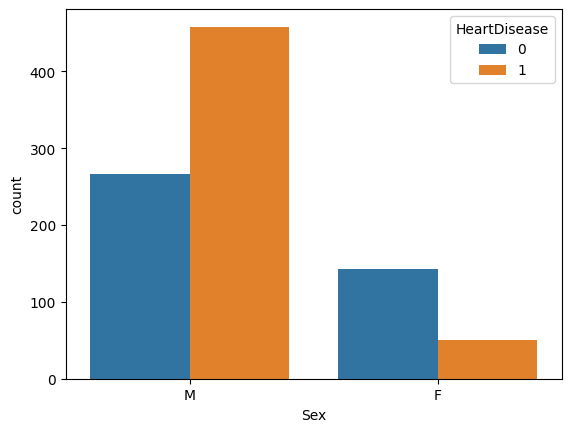

In [77]:
sns.countplot(x = 'Sex',hue = 'HeartDisease',data = df)

<Axes: xlabel='ChestPainType', ylabel='count'>

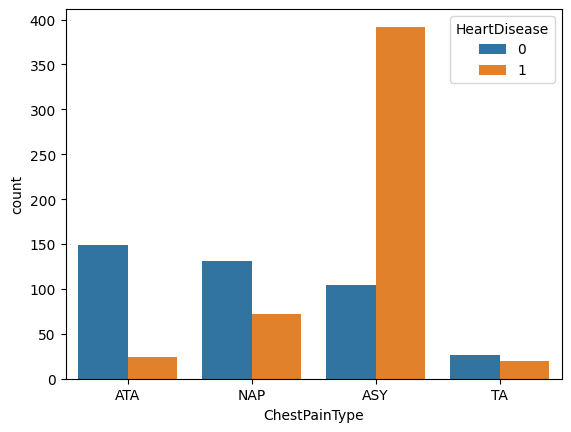

In [78]:
sns.countplot(x = 'ChestPainType',hue = 'HeartDisease',data = df)

Data Preprocessing

In [79]:
df_encode = pd.get_dummies(df,drop_first = True)
df_encode = df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [80]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()

df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,1,0,0,0,0,0,1,0


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [82]:
X = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [84]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [85]:
y_predict = model.predict(X_test)
y_predict

array([-0.06083902,  0.54920969,  0.92958975,  0.90674612,  0.08566811,
        0.86009151,  0.6781901 ,  0.13691588,  0.75146612,  0.75723625,
        0.54348692,  0.13949816,  0.72425349,  0.06488257,  0.91838888,
        0.45504247,  0.00694868,  0.65558672,  0.71896394,  0.46942677,
        0.54468653,  0.76294184,  0.06038889,  0.62930295,  0.81875216,
        0.90282261,  0.06231178,  0.63846153,  0.01329772,  0.00470266,
        0.67562302,  0.24039463,  0.62083753,  0.95115304,  0.94083831,
        0.4464975 ,  0.97004268,  0.06320934,  0.93942379,  0.68489152,
        0.83262518,  0.79365716,  0.54016853,  0.21218664,  0.15058068,
        0.72793285,  0.71677486,  1.04040915,  0.85733948,  0.31438443,
        0.04701078,  0.00609917,  0.70455607,  0.96621385,  0.56384376,
        0.2896648 ,  0.4231486 ,  0.86140373,  0.53135148,  0.76428667,
        0.22161155,  0.10442538, -0.11858971,  1.02833153, -0.0331765 ,
        1.04171301,  1.16620035,  0.88430356,  1.08858769,  0.56

In [86]:
y_test

,HeartDisease
668,0
30,1
377,1
535,1
807,0
...,...
164,0
28,0
514,1
193,0


In [87]:
r2 = r2_score(y_test,y_predict)
r2

0.5526415136474259

In [88]:
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
adj_r2

0.5292604080889289